In [10]:
import os
import glob
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
source_path = '/Users/harryclark/Downloads/COHORT12/'
locations = pd.read_csv('/Users/harryclark/Downloads/all_cluster_brain_locations_chris.csv')
locations['coord_SCs_x'] = locations['coord_SCs_x'] * -1

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import numpy as np

def make_annotations(mouse, path=None):
    Mouse = f'M{mouse}'

    data_paths = [f"/Users/harryclark/Documents/brainrender/probe_data/{Mouse}_probe_locations_{a}.mat" for a in [1,2,3,4]]
    shank_offsets_SC = pd.read_csv('/Users/harryclark/Documents/brainrender/probe_data/shank_offsets.csv')
    clusters_df = pd.read_csv(f'/Users/harryclark/Documents/brainrender/probe_data/extremum_channel_locations_kilosort4_0.csv')
    clusters_df = clusters_df[clusters_df['mouse'] == mouse]
    shank_offsets_SC = shank_offsets_SC[shank_offsets_SC['mouse'] == mouse]
    clusters_df = reconstruct_shank_id(clusters_df, mouse)
    probes_locs = [read_probe_mat(data_path) for data_path in data_paths]
    adjusted_probes_locs_CCF = np.array([adjust_probe_locs(probe_locs) for probe_locs in probes_locs])
    adjusted_probe_locs_SC, adjusted_probe_locs_CCF = correct_for_left_side(adjusted_probes_locs_CCF)
    adjusted_probe_locs_SC, adjusted_probe_locs_CCF = adjust_to_shank_offsets(adjusted_probe_locs_SC, shank_offsets_SC)
    
    ymin = -300; ymax = 3000
    xmin = -200; xmax = 1000
    xs = np.arange(xmin, xmax, 1)
    ys = np.arange(ymin, ymax, 1)

    if os.path.exists(f"{path}/M{mouse}_annotations.npy"):
        # Load annotations and colors from disk
        annotations = np.load(f"{path}/M{mouse}_annotations.npy", allow_pickle=True)
        annotation_colors = np.load(f"{path}/M{mouse}_annotation_colors.npy", allow_pickle=True)
        return annotations, annotation_colors, xs, ys
    
    else:
        annotations = np.zeros((len(ys), len(xs)), dtype=object)
        for yi, y in enumerate(ys):
            for xi, x in enumerate(xs):
                coord_SC, coord_CCF  = brain_coord_from_xy(x, y, adjusted_probe_locs_SC, shank_id=0)
                z_CCF, y_CCF, x_CCF = np.round(coord_CCF/10).astype(int)
                annotation_index = annotations_set[z_CCF,y_CCF,x_CCF]
                if len(structure_set[structure_set['id'] == annotation_index]) ==1:
                    annotation = structure_set[structure_set['id'] == annotation_index]['acronym'].iloc[0]
                else:
                    annotation ='root' # out of brain
                annotations[yi,xi] = annotation

        annotation_colors = get_annotation_colors_2D(annotations)

        # Save
        np.save(f"{path}/M{mouse}_annotations.npy", annotations)
        np.save(f"{path}/M{mouse}_annotation_colors.npy", annotation_colors)

    return annotations, annotation_colors, xs, ys

In [12]:
data_dir = '/Users/harryclark/Downloads/COHORT12/medial_lateral_xgboost/'
all_files = glob.glob(os.path.join(data_dir, "*.pkl"))

data = pd.DataFrame()
for file in all_files:
    data = pd.concat([data, pd.read_pickle(file)], ignore_index=True)

# Merge coord_SCs_x from locations into data using mouse, day, and target_cluster_id as keys
data = pd.merge(
    data,
    locations[['mouse', 'day', 'cluster_id', 'coord_SCs_x']],
    how='left',
    left_on=['mouse', 'day', 'target_cluster_id'],
    right_on=['mouse', 'day', 'cluster_id']
 )

In [13]:
# Find good GC examples with both medial and lateral covariate_pos_label entries
# Group by mouse, day, target_cluster_id, and target_pos_label, and filter for those with both covariate_pos_labels

# Only consider GC cells in medial_MEC
gc_medial = data[
    (data['target_cell_type'] == 'GC') &
    (data['target_pos_label'] == 'medial_MEC') &
    (data['n_covariate_cells'] > 0) &
    (data['include_position'] == True)
]

# Group by mouse, day, cluster, and keep only those with both covariate_pos_labels
grouped = gc_medial.groupby(['mouse', 'day', 'target_cluster_id'])

good_examples = []
for (mouse, day, cluster_id), group in grouped:
    cov_labels = set(group['covariate_pos_label'])
    if {'medial_MEC', 'lateral_MEC'}.issubset(cov_labels):
        # For each covariate_pos_label, print n_covariate_cells
        for cov_label in ['medial_MEC', 'lateral_MEC']:
            n_cov = group[group['covariate_pos_label'] == cov_label]['n_covariate_cells'].values
            print(f"Mouse: {mouse}, Day: {day}, Cluster: {cluster_id}, Covariate: {cov_label}, n_covariate_cells: {n_cov[0] if len(n_cov) > 0 else 'NA'}")
        good_examples.append((mouse, day, cluster_id))

# Optionally, print a summary of how many good examples were found
print(f"Total good examples found: {len(good_examples)}")

Mouse: 20, Day: 16, Cluster: 152, Covariate: medial_MEC, n_covariate_cells: 59
Mouse: 20, Day: 16, Cluster: 152, Covariate: lateral_MEC, n_covariate_cells: 95
Mouse: 21, Day: 16, Cluster: 482, Covariate: medial_MEC, n_covariate_cells: 56
Mouse: 21, Day: 16, Cluster: 482, Covariate: lateral_MEC, n_covariate_cells: 109
Mouse: 21, Day: 16, Cluster: 484, Covariate: medial_MEC, n_covariate_cells: 56
Mouse: 21, Day: 16, Cluster: 484, Covariate: lateral_MEC, n_covariate_cells: 109
Mouse: 21, Day: 16, Cluster: 485, Covariate: medial_MEC, n_covariate_cells: 56
Mouse: 21, Day: 16, Cluster: 485, Covariate: lateral_MEC, n_covariate_cells: 109
Mouse: 21, Day: 16, Cluster: 490, Covariate: medial_MEC, n_covariate_cells: 56
Mouse: 21, Day: 16, Cluster: 490, Covariate: lateral_MEC, n_covariate_cells: 109
Mouse: 21, Day: 16, Cluster: 495, Covariate: medial_MEC, n_covariate_cells: 56
Mouse: 21, Day: 16, Cluster: 495, Covariate: lateral_MEC, n_covariate_cells: 109
Mouse: 21, Day: 16, Cluster: 502, Covaria

In [16]:
good_mouse = 26
good_day = 19

# Find good GC examples with both medial and lateral covariate_pos_label entries
gc_medial = data[
    (data['target_cell_type'] == 'GC') &
    (data['target_pos_label'] == 'medial_MEC') &
    (data['n_covariate_cells'] > 0) &
    (data['include_position'] == True)
]

grouped = gc_medial.groupby(['mouse', 'day', 'target_cluster_id'])

good_examples = []
for (mouse, day, cluster_id), group in grouped:
    cov_labels = set(group['covariate_pos_label'])
    if {'medial_MEC', 'lateral_MEC'}.issubset(cov_labels):
        for cov_label in ['medial_MEC', 'lateral_MEC']:
            n_cov = group[group['covariate_pos_label'] == cov_label]['n_covariate_cells'].values
            print(f"Mouse: {mouse}, Day: {day}, Cluster: {cluster_id}, Covariate: {cov_label}, n_covariate_cells: {n_cov[0] if len(n_cov) > 0 else 'NA'}")
        good_examples.append((mouse, day, cluster_id))

filtered_good_examples = [(mouse, day, cluster_id) for (mouse, day, cluster_id) in good_examples if int(mouse) == good_mouse and int(day) == good_day]

print(f"Total good examples found: {len(good_examples)}")

Mouse: 20, Day: 16, Cluster: 152, Covariate: medial_MEC, n_covariate_cells: 59
Mouse: 20, Day: 16, Cluster: 152, Covariate: lateral_MEC, n_covariate_cells: 95
Mouse: 21, Day: 16, Cluster: 482, Covariate: medial_MEC, n_covariate_cells: 56
Mouse: 21, Day: 16, Cluster: 482, Covariate: lateral_MEC, n_covariate_cells: 109
Mouse: 21, Day: 16, Cluster: 484, Covariate: medial_MEC, n_covariate_cells: 56
Mouse: 21, Day: 16, Cluster: 484, Covariate: lateral_MEC, n_covariate_cells: 109
Mouse: 21, Day: 16, Cluster: 485, Covariate: medial_MEC, n_covariate_cells: 56
Mouse: 21, Day: 16, Cluster: 485, Covariate: lateral_MEC, n_covariate_cells: 109
Mouse: 21, Day: 16, Cluster: 490, Covariate: medial_MEC, n_covariate_cells: 56
Mouse: 21, Day: 16, Cluster: 490, Covariate: lateral_MEC, n_covariate_cells: 109
Mouse: 21, Day: 16, Cluster: 495, Covariate: medial_MEC, n_covariate_cells: 56
Mouse: 21, Day: 16, Cluster: 495, Covariate: lateral_MEC, n_covariate_cells: 109
Mouse: 21, Day: 16, Cluster: 502, Covaria


Mouse: 26, Day: 19, Cluster: 24
hi
plotting true rate map
for cell 24, avg pR2 (pos only) is -0.0002849669496088225, using 0 covariate cells
using expected spikes for cell 18
for cell 24, avg pR2 is 0.2634076749637166, for medial_MEC, using 70 covariate cells
using expected spikes for cell 18
hi
for cell 24, avg pR2 is 0.044669199233228304, for lateral_MEC, using 147 covariate cells
using expected spikes for cell 18
hi


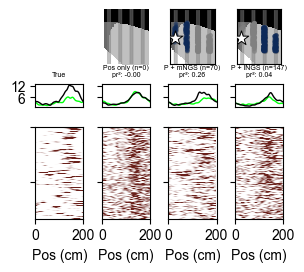


Mouse: 26, Day: 19, Cluster: 113
hi
plotting true rate map
for cell 113, avg pR2 (pos only) is 0.03996431934223168, using 0 covariate cells
using expected spikes for cell 18


KeyboardInterrupt: 

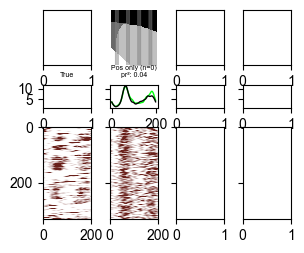

: 

In [ ]:
# For each good example cell, reconstruct firing rate profiles using xgboost predictions
# You will need to fill in the details for loading tcs_time, pos_in_time, and MLencoding setup

# set up xgboost history model
xgb_history = MLencoding(tunemodel='xgboost', cov_history=True, spike_history=False,
                            window=time_bs, n_filters=5, max_time=1000)

#filtered_good_examples = [(25,25,91), (25,25,235)]
for mouse, day, cluster_id in filtered_good_examples:
    print(f"\nMouse: {mouse}, Day: {day}, Cluster: {cluster_id}")
    gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95, verbose=False) # subset
    tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse,day, apply_zscore=False, apply_guassian_filter=False)
    last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

    # time binned variables for later
    ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
    speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep))
    dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl))
    pos_in_time = dt_in_time%tl
    trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

    if np.any(np.isnan(pos_in_time)):
        series = pd.Series(dt_in_time)
        filled_series = series.ffill().bfill()
        dt_in_time = np.array(filled_series)
        pos_in_time = dt_in_time%tl
        trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

    if np.any(np.isnan(speed_in_time)):
        series = pd.Series(speed_in_time)
        filled_series = series.ffill().bfill()
        speed_in_time = np.array(filled_series)

    # Get the target cell's firing rate
    target_fr = tcs_time[cluster_id]

    locations = pd.read_csv(f'{source_path}/all_cluster_brain_locations_chris.csv')
    locations = locations[(locations['mouse'] == mouse) & (locations['day'] == day)]
    locations['coord_SCs_x'] = locations['coord_SCs_x'] * -1  # correct for the flipped SCs x coordinates

    # Set up 4-column plot: True, Pos-only, Medial, Lateral
    fig, ax = plt.subplots(ncols=4, nrows=3, figsize=(rm_figsize[0]*3.2, rm_figsize[1]*1.7), 
                           sharex=False, sharey='row', height_ratios=[0.6, 0.25, 1], width_ratios=[1,1,1,1])
    plt.subplots_adjust(wspace=0.38, hspace=0.35)

    # --- Annotation plot above Pos-only column (no cells highlighted) ---
    annotations, annotation_colors, xs, ys = make_annotations(mouse, path='/Users/harryclark/Documents/spatial-manifolds/data')
    unique_colors = np.unique(annotation_colors)
    for color_ in unique_colors:
        border_points = extract_border(annotation_colors, color_, only_border=False)
        x_points = xs[border_points[:, 1]]
        y_points = ys[border_points[:, 0]]
        ax[0,1].scatter(x_points, y_points, color=color_, s=1, label=color_, rasterized=True)
    plot_NP2_probe(ax[0,1], sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', 
                probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
    ax[0,1].set_ylim([min_y, max_y])
    ax[0,1].set_xlim([-100, 900])
    ax[0,1].spines['top'].set_visible(True)
    ax[0,1].spines['right'].set_visible(True)
    ax[0,1].spines['bottom'].set_visible(True)
    ax[0,1].spines['left'].set_visible(True)

    # --- True rate map ---
    tc = tcs[cluster_id]
    tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
    tc = tc[:last_ephys_bin] # only want bins with ephys data in it
    tcz = zscore(tc)
    print(f'plotting true rate map')
    plot_firing_rate_map(ax[2,0], tc, bs=bs, tl=tl, p=95, sort_indices=None, cmap=white_to_hex_cmap('#69201a'))
    ax[1,0].set_title('True', fontsize=5)

    # --- Position-only (n=0) reconstruction ---
    X_posonly = pos_in_time.reshape(-1, 1)
    Y_hat_pos, pR2_cv_pos = xgb_history.fit_cv(X_posonly, target_fr, verbose=0, continuous_folds=True)
    print(f'for cell {cluster_id}, avg pR2 (pos only) is {np.nanmean(pR2_cv_pos)}, using 0 covariate cells')
    expected_spikes_pos = {ns.cluster_id.values[0]: Y_hat_pos}
    tcs_expected_spikes_pos, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs_using_expected_spikes(
        mouse, day, apply_zscore=False, apply_guassian_filter=False, vr_type='VR', source_path=source_path, expected_spikes=expected_spikes_pos)
    tc_es_pos = tcs_expected_spikes_pos[ns.cluster_id.values[0]]
    tc_es_pos = gaussian_filter(np.nan_to_num(tc_es_pos).astype(np.float64), sigma=2.5)
    tc_es_pos = tc_es_pos[:last_ephys_bin]
    plot_firing_rate_map(ax[2,1], tc_es_pos, bs=bs, tl=tl, p=95, sort_indices=None, cmap=white_to_hex_cmap('#69201a'))
    ax[1,1].set_title(f'Pos only (n=0)\npr²: {np.nanmean(pR2_cv_pos):.2f}', fontsize=5)

    # Plot average firing rate profile for Pos only
    trial_groups, trial_colors = get_trial_groups_and_colors(beh, last_ephys_bin, tl, bs, ignore_performance=True)
    for group in np.unique(trial_groups):
        if len(trial_groups[trial_groups == group]) > 5:
            x, y = get_avg_profile(tc_es_pos, bs, tl, mask=trial_groups==group)
            ax[1,1].plot(x, y, color=trial_colors[trial_groups==group][0], linewidth=1)
    # Only allow max two y ticks on 2nd row
    for col in range(4):
        ax[1,col].yaxis.set_major_locator(plt.MaxNLocator(nbins=2, integer=True))
    # Remove axis from 1st row, 2nd column only
    ax[0,1].axis('off')

    # --- Medial and Lateral reconstructions ---
    tidy_labels = {'medial_MEC': 'P + mNGS', 'lateral_MEC': 'P + lNGS'}
    for cov_idx, cov_label in enumerate(['medial_MEC', 'lateral_MEC']):
        # Get covariate NGS cluster_ids in the correct ML bin
        cov_bounds = (-np.inf, 3400) if cov_label == 'medial_MEC' else (3400, np.inf)
        covariate_cluster_ids = ngs.cluster_id.values.astype(int)
        covariate_cluster_ids = covariate_cluster_ids[
            np.isin(
                covariate_cluster_ids,
                locations[
                    (locations['coord_SCs_x'] >= cov_bounds[0]) &
                    (locations['coord_SCs_x'] < cov_bounds[1])
                ]['cluster_id'].values.astype(int)
            )
        ]

        # Build covariate matrix X (n_timepoints x n_covariate_cells)
        cov_tcs_time = {cid: tcs_time[cid] for cid in covariate_cluster_ids if cid in tcs_time}
        if len(cov_tcs_time) == 0:
            print(f"No covariate cells found for {cov_label}")
            continue
        X = np.vstack(list(cov_tcs_time.values())).T
        X = np.column_stack((pos_in_time, X))
        n_cov_cells = len(X.T)-1 # subtract 1 for position
        Y_hat, pR2_cv = xgb_history.fit_cv(X, target_fr, verbose=0, continuous_folds=True)
        print(f'for cell {cluster_id}, avg pR2 is {np.nanmean(pR2_cv)}, for {cov_label}, using {n_cov_cells} covariate cells')
        expected_spikes = {ns.cluster_id.values[0]: Y_hat}
        tcs_expected_spikes, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs_using_expected_spikes(
            mouse, day, apply_zscore=False, apply_guassian_filter=False, vr_type='VR', source_path=source_path, expected_spikes=expected_spikes)
        tc_es = tcs_expected_spikes[ns.cluster_id.values[0]]
        tc_es = gaussian_filter(np.nan_to_num(tc_es).astype(np.float64), sigma=2.5)
        tc_es = tc_es[:last_ephys_bin]
        plot_firing_rate_map(ax[2,cov_idx+2], tc_es, bs=bs, tl=tl, p=95, sort_indices=None, cmap=white_to_hex_cmap('#69201a'))
        ax[1,cov_idx+2].set_title(f'{tidy_labels[cov_label]} (n={n_cov_cells})\npr²: {np.nanmean(pR2_cv):.2f}', fontsize=5)

        # Plot trial-averaged profiles for each group
        for group in np.unique(trial_groups):
            if len(trial_groups[trial_groups == group]) > 5:
                x, y = get_avg_profile(tc, bs, tl, mask=trial_groups==group)
                if cov_idx == 0:
                    ax[1,0].plot(x, y, color=trial_colors[trial_groups==group][0], linewidth=1)
                x, y = get_avg_profile(tc_es, bs, tl, mask=trial_groups==group)
                ax[1,cov_idx+2].plot(x, y, color=trial_colors[trial_groups==group][0], linewidth=1)

        # Plot probe locations and cell highlights for each covariate column
        annotations, annotation_colors, xs, ys = make_annotations(mouse, path='/Users/harryclark/Documents/spatial-manifolds/data')
        unique_colors = np.unique(annotation_colors)
        for color_ in unique_colors:
            border_points = extract_border(annotation_colors, color_, only_border=False)
            x_points = xs[border_points[:, 1]]
            y_points = ys[border_points[:, 0]]
            ax[0,cov_idx+2].scatter(x_points, y_points, color=color_, s=1, label=color_, rasterized=True)
        plot_NP2_probe(ax[0,cov_idx+2], sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', 
                    probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
        ax[0,cov_idx+2].scatter(ngs.probe_x.values, ngs.probe_y.values, marker='o', color="grey", alpha=0.4, s=7)
        ax[0,cov_idx+2].scatter(gcs.probe_x.values, gcs.probe_y.values, marker='o', color="grey", alpha=0.4, s=7)
        min_y = min(all['probe_y'].values) - 300
        max_y = max(all['probe_y'].values) + 300
        target_id = cluster_id
        target_row = all[all['cluster_id'] == target_id]
        # Move star scatter after all other scatter points for highest zorder
        if not target_row.empty:
            x_t, y_t = target_row['probe_x'].values[0], target_row['probe_y'].values[0]
            ax[0,cov_idx+2].scatter(x_t, y_t, marker='*', s=120, color='white', edgecolor='black', linewidth=0.7, zorder=100)
        cov_row = all[np.isin(all['cluster_id'], covariate_cluster_ids)]
        if not cov_row.empty:
            for _, row in cov_row.iterrows():
                x_c, y_c = row['probe_x'], row['probe_y']
                from matplotlib.patches import Circle
                circ2 = Circle((x_c, y_c), radius=20, edgecolor='#0d2958', facecolor='#0d2958', lw=2, alpha=0.6, zorder=12)
                ax[0,cov_idx+2].add_patch(circ2)
        ax[0,cov_idx+2].set_ylim([min_y, max_y])
        ax[0,cov_idx+2].set_xlim([-100, 900])
        ax[0,cov_idx+2].spines['top'].set_visible(True)
        ax[0,cov_idx+2].spines['right'].set_visible(True)
        ax[0,cov_idx+2].spines['bottom'].set_visible(True)
        ax[0,cov_idx+2].spines['left'].set_visible(True)

    # Set axis labels and hide unused axes
    ax[2,0].set_xlabel('Pos (cm)')
    ax[2,1].set_xlabel('Pos (cm)')
    ax[2,2].set_xlabel('Pos (cm)')
    ax[2,3].set_xlabel('Pos (cm)')
    # Only show y tick labels on the 3rd row, 1st column
    ax[2,1].set_yticklabels([])
    ax[2,2].set_yticklabels([])
    ax[2,3].set_yticklabels([])
    ax[1,2].set_xticks([])
    ax[1,3].set_xticks([])
    ax[1,1].set_xticks([])
    ax[1,0].set_xticks([])
    ax[1,0].set_xlim([0,200])
    ax[1,1].set_xlim([0,200])
    ax[1,2].set_xlim([0,200])
    ax[1,3].set_xlim([0,200])
    ax[0,0].axis('off')
    plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/example_cell_{mouse}_day{day}_cluster{cluster_id}.pdf', dpi=300, bbox_inches='tight')
    plt.show()


Mouse: 25, Day: 25, Cluster: 91
hi
hi
plotting true rate map
plotting true rate map
for cell 91, avg pR2 (pos only) is 0.031157109238115443, using 0 covariate cells
for cell 91, avg pR2 (pos only) is 0.031157109238115443, using 0 covariate cells
using expected spikes for cell 8
using expected spikes for cell 8
for cell 91, avg pR2 is 0.1525918879361235, for medial_MEC, using 20 covariate cells
for cell 91, avg pR2 is 0.1525918879361235, for medial_MEC, using 20 covariate cells
using expected spikes for cell 8
using expected spikes for cell 8
hi
hi
for cell 91, avg pR2 is 0.06316352092804528, for lateral_MEC, using 36 covariate cells
for cell 91, avg pR2 is 0.06316352092804528, for lateral_MEC, using 36 covariate cells
using expected spikes for cell 8
using expected spikes for cell 8
hi
hi


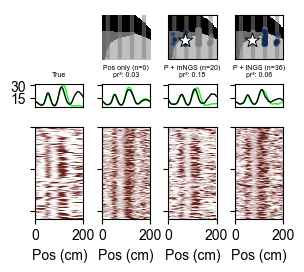


Mouse: 25, Day: 25, Cluster: 235
hi
hi
plotting true rate map
plotting true rate map
for cell 235, avg pR2 (pos only) is 0.03460785619373084, using 0 covariate cells
for cell 235, avg pR2 (pos only) is 0.03460785619373084, using 0 covariate cells
using expected spikes for cell 8
using expected spikes for cell 8
for cell 235, avg pR2 is 0.1275527295555207, for medial_MEC, using 20 covariate cells
for cell 235, avg pR2 is 0.1275527295555207, for medial_MEC, using 20 covariate cells
using expected spikes for cell 8
using expected spikes for cell 8
hi
hi
for cell 235, avg pR2 is 0.08162561051169955, for lateral_MEC, using 36 covariate cells
for cell 235, avg pR2 is 0.08162561051169955, for lateral_MEC, using 36 covariate cells
using expected spikes for cell 8
using expected spikes for cell 8
hi
hi


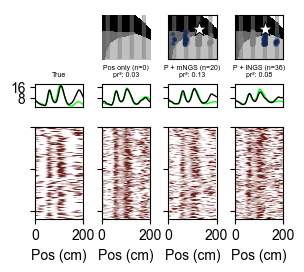

In [ ]:
# For each good example cell, reconstruct firing rate profiles using xgboost predictions
# You will need to fill in the details for loading tcs_time, pos_in_time, and MLencoding setup

# set up xgboost history model
xgb_history = MLencoding(tunemodel='xgboost', cov_history=True, spike_history=False,
                            window=time_bs, n_filters=5, max_time=1000)

filtered_good_examples = [(25,25,91), (25,25,235)]
for mouse, day, cluster_id in filtered_good_examples:
    print(f"\nMouse: {mouse}, Day: {day}, Cluster: {cluster_id}")
    gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95, verbose=False) # subset
    tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse,day, apply_zscore=False, apply_guassian_filter=False)
    last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

    gcs = reconstruct_shank_id(gcs)
    ngs = reconstruct_shank_id(ngs)
    # time binned variables for later
    ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
    speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep))
    dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl))
    pos_in_time = dt_in_time%tl
    trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

    if np.any(np.isnan(pos_in_time)):
        series = pd.Series(dt_in_time)
        filled_series = series.ffill().bfill()
        dt_in_time = np.array(filled_series)
        pos_in_time = dt_in_time%tl
        trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

    if np.any(np.isnan(speed_in_time)):
        series = pd.Series(speed_in_time)
        filled_series = series.ffill().bfill()
        speed_in_time = np.array(filled_series)

    # Get the target cell's firing rate
    target_fr = tcs_time[cluster_id]

    locations = pd.read_csv(f'{source_path}/all_cluster_brain_locations_chris.csv')
    locations = locations[(locations['mouse'] == mouse) & (locations['day'] == day)]
    locations['coord_SCs_x'] = locations['coord_SCs_x'] * -1  # correct for the flipped SCs x coordinates

    # Set up 4-column plot: True, Pos-only, Medial, Lateral
    fig, ax = plt.subplots(ncols=4, nrows=3, figsize=(rm_figsize[0]*3.2, rm_figsize[1]*1.7), 
                           sharex=False, sharey='row', height_ratios=[0.6, 0.25, 1], width_ratios=[1,1,1,1])
    plt.subplots_adjust(wspace=0.38, hspace=0.35)

    # --- Annotation plot above Pos-only column (no cells highlighted) ---
    annotations, annotation_colors, xs, ys = make_annotations(mouse, path='/Users/harryclark/Documents/spatial-manifolds/data')
    unique_colors = np.unique(annotation_colors)
    for color_ in unique_colors:
        border_points = extract_border(annotation_colors, color_, only_border=False)
        x_points = xs[border_points[:, 1]]
        y_points = ys[border_points[:, 0]]
        ax[0,1].scatter(x_points, y_points, color=color_, s=1, label=color_, rasterized=True)
    plot_NP2_probe(ax[0,1], sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', 
                probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
    ax[0,1].set_ylim([min_y, max_y])
    ax[0,1].set_xlim([-100, 900])
    ax[0,1].spines['top'].set_visible(True)
    ax[0,1].spines['right'].set_visible(True)
    ax[0,1].spines['bottom'].set_visible(True)
    ax[0,1].spines['left'].set_visible(True)

    # --- True rate map ---
    tc = tcs[cluster_id]
    tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
    tc = tc[:last_ephys_bin] # only want bins with ephys data in it
    tcz = zscore(tc)
    print(f'plotting true rate map')
    plot_firing_rate_map(ax[2,0], tc, bs=bs, tl=tl, p=95, sort_indices=None, cmap=white_to_hex_cmap('#69201a'))
    ax[1,0].set_title('True', fontsize=5)

    # --- Position-only (n=0) reconstruction ---
    X_posonly = pos_in_time.reshape(-1, 1)
    Y_hat_pos, pR2_cv_pos = xgb_history.fit_cv(X_posonly, target_fr, verbose=0, continuous_folds=True)
    print(f'for cell {cluster_id}, avg pR2 (pos only) is {np.nanmean(pR2_cv_pos)}, using 0 covariate cells')
    expected_spikes_pos = {ns.cluster_id.values[0]: Y_hat_pos}
    tcs_expected_spikes_pos, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs_using_expected_spikes(
        mouse, day, apply_zscore=False, apply_guassian_filter=False, vr_type='VR', source_path=source_path, expected_spikes=expected_spikes_pos)
    tc_es_pos = tcs_expected_spikes_pos[ns.cluster_id.values[0]]
    tc_es_pos = gaussian_filter(np.nan_to_num(tc_es_pos).astype(np.float64), sigma=2.5)
    tc_es_pos = tc_es_pos[:last_ephys_bin]
    plot_firing_rate_map(ax[2,1], tc_es_pos, bs=bs, tl=tl, p=95, sort_indices=None, cmap=white_to_hex_cmap('#69201a'))
    ax[1,1].set_title(f'Pos only (n=0)\npr²: {np.nanmean(pR2_cv_pos):.2f}', fontsize=5)

    # Plot average firing rate profile for Pos only
    trial_groups, trial_colors = get_trial_groups_and_colors(beh, last_ephys_bin, tl, bs, ignore_performance=True)
    for group in np.unique(trial_groups):
        if len(trial_groups[trial_groups == group]) > 5:
            x, y = get_avg_profile(tc_es_pos, bs, tl, mask=trial_groups==group)
            ax[1,1].plot(x, y, color=trial_colors[trial_groups==group][0], linewidth=1)
    # Only allow max two y ticks on 2nd row
    for col in range(4):
        ax[1,col].yaxis.set_major_locator(plt.MaxNLocator(nbins=2, integer=True))
    # Remove axis from 1st row, 2nd column only
    ax[0,1].axis('off')

    # --- Medial and Lateral reconstructions ---
    tidy_labels = {'medial_MEC': 'P + mNGS', 'lateral_MEC': 'P + lNGS'}
    for cov_idx, cov_label in enumerate(['medial_MEC', 'lateral_MEC']):
        # Get covariate NGS cluster_ids in the correct ML bin
        cov_bounds = (-np.inf, 3400) if cov_label == 'medial_MEC' else (3400, np.inf)
        covariate_cluster_ids = ngs.cluster_id.values.astype(int)
        covariate_cluster_ids = covariate_cluster_ids[
            np.isin(
                covariate_cluster_ids,
                locations[
                    (locations['coord_SCs_x'] >= cov_bounds[0]) &
                    (locations['coord_SCs_x'] < cov_bounds[1])
                ]['cluster_id'].values.astype(int)
            )
        ]

        # Build covariate matrix X (n_timepoints x n_covariate_cells)
        cov_tcs_time = {cid: tcs_time[cid] for cid in covariate_cluster_ids if cid in tcs_time}
        if len(cov_tcs_time) == 0:
            print(f"No covariate cells found for {cov_label}")
            continue
        X = np.vstack(list(cov_tcs_time.values())).T
        X = np.column_stack((pos_in_time, X))
        n_cov_cells = len(X.T)-1 # subtract 1 for position
        Y_hat, pR2_cv = xgb_history.fit_cv(X, target_fr, verbose=0, continuous_folds=True)
        print(f'for cell {cluster_id}, avg pR2 is {np.nanmean(pR2_cv)}, for {cov_label}, using {n_cov_cells} covariate cells')
        expected_spikes = {ns.cluster_id.values[0]: Y_hat}
        tcs_expected_spikes, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs_using_expected_spikes(
            mouse, day, apply_zscore=False, apply_guassian_filter=False, vr_type='VR', source_path=source_path, expected_spikes=expected_spikes)
        tc_es = tcs_expected_spikes[ns.cluster_id.values[0]]
        tc_es = gaussian_filter(np.nan_to_num(tc_es).astype(np.float64), sigma=2.5)
        tc_es = tc_es[:last_ephys_bin]
        plot_firing_rate_map(ax[2,cov_idx+2], tc_es, bs=bs, tl=tl, p=95, sort_indices=None, cmap=white_to_hex_cmap('#69201a'))
        ax[1,cov_idx+2].set_title(f'{tidy_labels[cov_label]} (n={n_cov_cells})\npr²: {np.nanmean(pR2_cv):.2f}', fontsize=5)

        # Plot trial-averaged profiles for each group
        for group in np.unique(trial_groups):
            if len(trial_groups[trial_groups == group]) > 5:
                x, y = get_avg_profile(tc, bs, tl, mask=trial_groups==group)
                if cov_idx == 0:
                    ax[1,0].plot(x, y, color=trial_colors[trial_groups==group][0], linewidth=1)
                x, y = get_avg_profile(tc_es, bs, tl, mask=trial_groups==group)
                ax[1,cov_idx+2].plot(x, y, color=trial_colors[trial_groups==group][0], linewidth=1)

        # Plot probe locations and cell highlights for each covariate column
        annotations, annotation_colors, xs, ys = make_annotations(mouse, path='/Users/harryclark/Documents/spatial-manifolds/data')
        unique_colors = np.unique(annotation_colors)
        for color_ in unique_colors:
            border_points = extract_border(annotation_colors, color_, only_border=False)
            x_points = xs[border_points[:, 1]]
            y_points = ys[border_points[:, 0]]
            ax[0,cov_idx+2].scatter(x_points, y_points, color=color_, s=1, label=color_, rasterized=True)
        plot_NP2_probe(ax[0,cov_idx+2], sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', 
                    probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
        ax[0,cov_idx+2].scatter(ngs.probe_x.values, ngs.probe_y.values, marker='o', color="grey", alpha=0.4, s=7)
        ax[0,cov_idx+2].scatter(gcs.probe_x.values, gcs.probe_y.values, marker='o', color="grey", alpha=0.4, s=7)
        min_y = min(all['probe_y'].values) - 300
        max_y = max(all['probe_y'].values) + 300
        target_id = cluster_id
        target_row = all[all['cluster_id'] == target_id]
        # Move star scatter after all other scatter points for highest zorder
        if not target_row.empty:
            x_t, y_t = target_row['probe_x'].values[0], target_row['probe_y'].values[0]
            ax[0,cov_idx+2].scatter(x_t, y_t, marker='*', s=120, color='white', edgecolor='black', linewidth=0.7, zorder=100)
        cov_row = all[np.isin(all['cluster_id'], covariate_cluster_ids)]
        if not cov_row.empty:
            for _, row in cov_row.iterrows():
                x_c, y_c = row['probe_x'], row['probe_y']
                from matplotlib.patches import Circle
                circ2 = Circle((x_c, y_c), radius=20, edgecolor='#0d2958', facecolor='#0d2958', lw=2, alpha=0.6, zorder=12)
                ax[0,cov_idx+2].add_patch(circ2)
        ax[0,cov_idx+2].set_ylim([min_y, max_y])
        ax[0,cov_idx+2].set_xlim([-100, 900])
        ax[0,cov_idx+2].spines['top'].set_visible(True)
        ax[0,cov_idx+2].spines['right'].set_visible(True)
        ax[0,cov_idx+2].spines['bottom'].set_visible(True)
        ax[0,cov_idx+2].spines['left'].set_visible(True)

    # Set axis labels and hide unused axes
    ax[2,0].set_xlabel('Pos (cm)')
    ax[2,1].set_xlabel('Pos (cm)')
    ax[2,2].set_xlabel('Pos (cm)')
    ax[2,3].set_xlabel('Pos (cm)')
    # Only show y tick labels on the 3rd row, 1st column
    ax[2,1].set_yticklabels([])
    ax[2,2].set_yticklabels([])
    ax[2,3].set_yticklabels([])
    ax[1,2].set_xticks([])
    ax[1,3].set_xticks([])
    ax[1,1].set_xticks([])
    ax[1,0].set_xticks([])
    ax[1,0].set_xlim([0,200])
    ax[1,1].set_xlim([0,200])
    ax[1,2].set_xlim([0,200])
    ax[1,3].set_xlim([0,200])
    ax[0,0].axis('off')
    plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/example_cell_{mouse}_day{day}_cluster{cluster_id}.pdf', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

# Define two shades of red
red_palette = ["#c04744", "#c04744"]

for pos_in_cov in [True, False]:
    data_ = data[data['include_position'] == pos_in_cov]

    labels = list(data_['covariate_pos_label'].unique())
    fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

    x_bins = np.arange(2900, 3900, 100)
    x_centers = 0.5 * (x_bins[:-1] + x_bins[1:])

    for i, (label, color) in enumerate(zip(labels, red_palette)):
        ax = axes[i]
        subset = data_[data_['covariate_pos_label'] == label].copy()
        sns.scatterplot(
            data=subset,
            x='coord_SCs_x',
            y='pR2_cv',
            color=color,
            alpha=0.7,
            ax=ax
        )

        subset['mouse_day'] = subset['mouse'].astype(str) + '_' + subset['day'].astype(str)
        subset['mouse_day_cluster'] = subset['mouse_day'] + '_' + subset['target_cluster_id'].astype(str)
        model = smf.mixedlm(
            "pR2_cv ~ coord_SCs_x + n_covariate_cells",
            subset,
            groups=subset["mouse"],
            re_formula="1",
            vc_formula={
                "mouse_day": "0 + C(mouse_day)",
                "mouse_day_cluster": "0 + C(mouse_day_cluster)"
            }
        )
        result = model.fit()
        print(result.summary())
        intercept = result.params['Intercept']
        slope = result.params['coord_SCs_x']
        cov_cells_effect = result.params.get('n_covariate_cells', 0)
        mean_cov_cells = subset['n_covariate_cells'].mean()
        y_fit = intercept + slope * x_centers + cov_cells_effect * mean_cov_cells

        # Bin SEM calculation (fixed bin edges)
        sems = []
        for j in range(len(x_bins)-1):
            bin_mask = (subset['coord_SCs_x'] >= x_bins[j]) & (subset['coord_SCs_x'] < x_bins[j+1])
            bin_sem = subset.loc[bin_mask, 'pR2_cv'].sem()
            sems.append(bin_sem if not np.isnan(bin_sem) else 0)
        sems = np.array(sems)

        ax.plot(x_centers, y_fit, color=color, label=f'LMM fit', linewidth=2)
        ax.fill_between(x_centers, y_fit - sems, y_fit + sems, color=color, alpha=0.2)

        # Annotate p-value at the rightmost part of the fit line
        pval = result.pvalues.get('coord_SCs_x', None)
        if pval is not None:
            y_annot = y_fit[-1] + sems[-1] + 0.01
            ax.text(x_centers[-1], y_annot, f'p={pval:.2g}', color=color, fontsize=12, ha='right', va='bottom', fontweight='bold')

        ax.set_xlim(2900, 3800)
        ax.axvline(3400, linestyle='dashed', color='black')
        ax.set_xlabel('Medial-lateral (μm)')
        if i == 0:
            ax.set_ylabel('Grid cell pR²')
        fig.tight_layout()

        if pos_in_cov:
            ax.set_title(f'Covariate: P + {label}')
            plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/absolute_pr2_grid_cells_split_pos.pdf')
        else:
            ax.set_title(f'Covariate: {label}')
            plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/absolute_pr2_grid_cells_split_no_pos.pdf')
    plt.show()

             Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    pR2_diff
No. Observations:     770        Method:                REML    
No. Groups:           8          Scale:                 0.0045  
Min. group size:      2          Log-Likelihood:        908.2294
Max. group size:      204        Converged:             No      
Mean group size:      96.2                                      
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             -0.297    0.074 -4.013 0.000 -0.442 -0.152
coord_SCs_x            0.000    0.000  3.439 0.001  0.000  0.000
n_covariate_cells      0.001    0.000 15.166 0.000  0.001  0.001
Group Var              0.004                                    
mouse_day Var          0.004                                    
mouse_day_cluster Var  0.000    0.029  

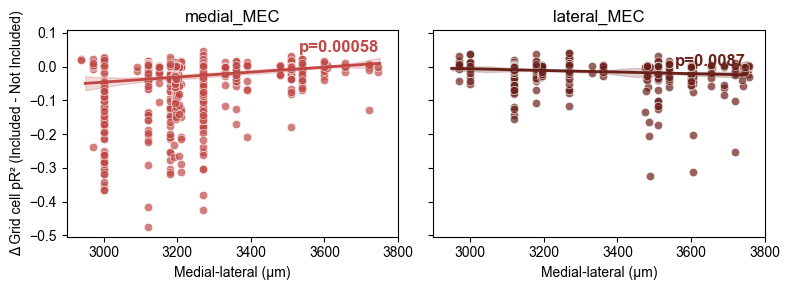

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

# Calculate pR2 difference for each unique group
group_cols = ['target_cluster_id', 'covariate_pos_label', 'mouse', 'day']
df_true = data[data['include_position'] == True].copy()
df_false = data[data['include_position'] == False].copy()

# Merge on group_cols to align True/False rows
merged = pd.merge(
    df_true[group_cols + ['pR2_cv', 'coord_SCs_x', 'n_covariate_cells']],
    df_false[group_cols + ['pR2_cv']],
    on=group_cols,
    suffixes=('_true', '_false')
 )
merged['pR2_diff'] = merged['pR2_cv_true'] - merged['pR2_cv_false']

# Plot on two subplots, one for each covariate_pos_label
red_palette = ["#c04744", "#69201a"]
labels = list(merged['covariate_pos_label'].unique())
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
x_bins = np.arange(2900, 3900, 100)
x_centers = 0.5 * (x_bins[:-1] + x_bins[1:])

for i, (label, color) in enumerate(zip(labels, red_palette)):
    ax = axes[i]
    subset = merged[merged['covariate_pos_label'] == label].copy()
    sns.scatterplot(
        data=subset,
        x='coord_SCs_x',
        y='pR2_diff',
        color=color,
        alpha=0.7,
        ax=ax
    )

    subset['mouse_day'] = subset['mouse'].astype(str) + '_' + subset['day'].astype(str)
    subset['mouse_day_cluster'] = subset['mouse_day'] + '_' + subset['target_cluster_id'].astype(str)
    if len(subset) > 0:
        model = smf.mixedlm(
            "pR2_diff ~ coord_SCs_x + n_covariate_cells",
            subset,
            groups=subset["mouse"],
            re_formula="1",
            vc_formula={
                "mouse_day": "0 + C(mouse_day)",
                "mouse_day_cluster": "0 + C(mouse_day_cluster)"
            }
        )
        result = model.fit()
        print(result.summary())
        intercept = result.params['Intercept']
        slope = result.params['coord_SCs_x']
        cov_cells_effect = result.params.get('n_covariate_cells', 0)
        mean_cov_cells = subset['n_covariate_cells'].mean()
        y_fit = intercept + slope * x_centers + cov_cells_effect * mean_cov_cells

        # Bin SEM calculation (fixed bin edges)
        sems = []
        for j in range(len(x_bins)-1):
            bin_mask = (subset['coord_SCs_x'] >= x_bins[j]) & (subset['coord_SCs_x'] < x_bins[j+1])
            bin_sem = subset.loc[bin_mask, 'pR2_diff'].sem()
            sems.append(bin_sem if not np.isnan(bin_sem) else 0)
        sems = np.array(sems)

        ax.plot(x_centers, y_fit, color=color, label=f'LMM fit', linewidth=2)
        ax.fill_between(x_centers, y_fit - sems, y_fit + sems, color=color, alpha=0.2)

        # Annotate p-value at the rightmost part of the fit line
        pval = result.pvalues.get('coord_SCs_x', None)
        if pval is not None:
            y_annot = y_fit[-1] + sems[-1] + 0.01
            ax.text(x_centers[-1], y_annot, f'p={pval:.2g}', color=color, fontsize=12, ha='right', va='bottom', fontweight='bold')

    ax.set_xlim(2900, 3800)
    ax.set_xlabel('Medial-lateral (μm)')
    if i == 0:
        ax.set_ylabel('Δ Grid cell pR² (Included - Not Included)')
    ax.set_title(label)

fig.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/absolute_pr2_grid_cells_diff_inclusion_subplots.pdf')
plt.show()

In [ ]:
import os
import glob

data_dir = '/Users/harryclark/Downloads/COHORT12/xgboost_task_anchoring'
all_files = glob.glob(os.path.join(data_dir, "*.csv"))

dataX = pd.DataFrame()
for file in all_files:
    df = pd.read_csv(file)

    if 'X_pos_cov' not in df.columns or 'Y_pos_cov' not in df.columns:
        print(f"Skipping file {file} due to missing columns.")
        continue

    dataX = pd.concat([dataX, df], ignore_index=True)

In [ ]:
dataX

In [ ]:
# Combine keys in data and dataX
data['unique_id'] = data['target_cluster_id'].astype(str) + '_' + data['mouse'].astype(str) + '_' + data['day'].astype(str)
dataX['unique_id'] = dataX['cluster_id'].astype(str) + '_' + dataX['mouse'].astype(str) + '_' + dataX['day'].astype(str)

# Find n_neurons==0 for each unique_id in dataX
dataX= dataX[dataX['n_neurons'] == 0]


In [ ]:
data

In [ ]:
# Get unique rows from data based on unique_id
unique_rows = data.drop_duplicates(subset=['unique_id'])[['target_cluster_id', 'mouse', 'day', 'unique_id']]

# Filter dataX for n_neurons == 0
dataX_0 = dataX[dataX['n_neurons'] == 0].copy()
dataX_0 = dataX_0.drop_duplicates(subset=['unique_id'])[['cluster_id', 'mouse', 'day', 'unique_id', 'pR2_cv', 'tested_on']]
dataX_0 = dataX_0[(dataX_0['tested_on'] == 'ncmGC') | 
                  (dataX_0['tested_on'] == 'cmGC') |
                  (dataX_0['tested_on'] == 'GC')]
dataX_0

In [ ]:
dataX_0